In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

In [12]:
og_df = pd.read_csv("../../data/SpotGenTrack/Data Sources/spotify_tracks.csv", index_col=0)
low_df = pd.read_csv("../../data/SpotGenTrack/Features Extracted/low_level_audio_features.csv", index_col=0)

df = pd.merge(
    low_df,
    og_df[["id", "popularity"]],
    left_on="track_id",
    right_on="id",
    how="inner"
)

df = df.drop(columns=["id"])

In [15]:
target = "popularity"

X = df.drop(columns=["popularity", "track_id"])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.10,
    random_state=42
)

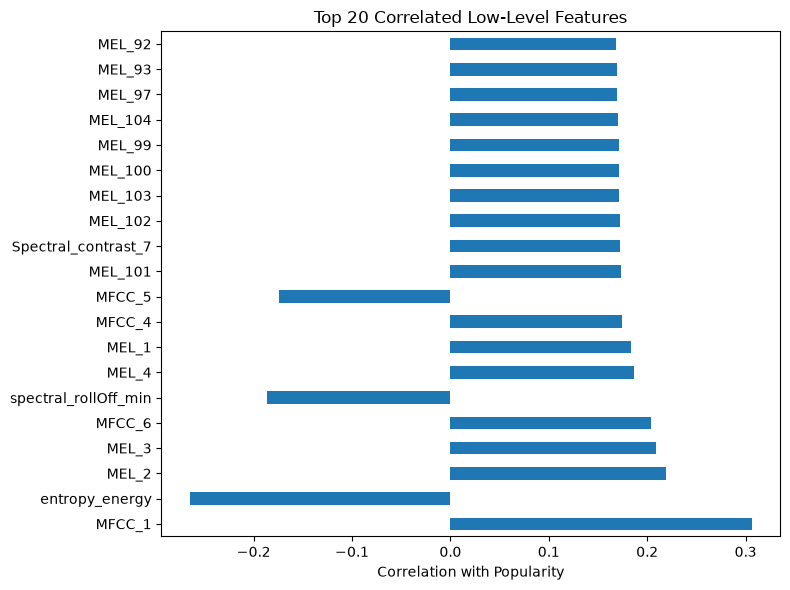

In [18]:
train_df = X_train.copy()
train_df[target] = y_train

correlations = (
    train_df.corr(numeric_only=True)[target]
    .drop(target)
)

correlations = correlations.reindex(
    correlations.abs().sort_values(ascending=False).index
)

correlations.head(20).plot(kind="barh", figsize=(8,6))
plt.xlabel("Correlation with Popularity")
plt.title("Top 20 Correlated Low-Level Features")
plt.tight_layout()
plt.show()

In [21]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_leaf=5,
    min_samples_split=10,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_train_pred = rf.predict(X_train)
y_val_pred = rf.predict(X_val)
y_test_pred = rf.predict(X_test)

train_r2 = r2_score(y_train, y_train_pred)
val_r2 = r2_score(y_val, y_val_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

train_mae = mean_absolute_error(y_train, y_train_pred)
val_mae = mean_absolute_error(y_val, y_val_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

print(f"Train R2: {train_r2:.4f}")
print(f"Validation R2: {val_r2:.4f}")
print(f"Test R2: {test_r2:.4f}")

print(f"Train RMSE: {train_rmse:.4f}")
print(f"Validation RMSE: {val_rmse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")

print(f"Train MAE: {train_mae:.4f}")
print(f"Validation MAE: {val_mae:.4f}")
print(f"Test MAE: {test_mae:.4f}")

Train R2: 0.4813
Validation R2: 0.2638
Test R2: 0.2708
Train RMSE: 12.1081
Validation RMSE: 14.3219
Test RMSE: 14.3013
Train MAE: 9.6273
Validation MAE: 11.5049
Test MAE: 11.4361


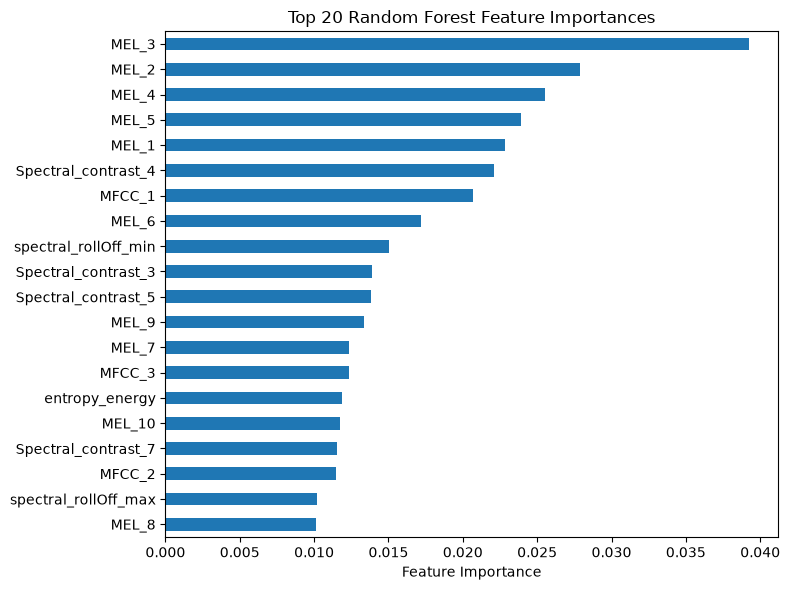

In [22]:
importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
importance.head(20).plot(kind="barh")
plt.xlabel("Feature Importance")
plt.title("Top 20 Random Forest Feature Importances")
plt.gca().invert_yaxis()  # Most important at the top
plt.tight_layout()
plt.show()